In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import RFE

In [250]:
data = pd.read_csv("D:/Programs/codentry-AIML/Lab_Management_system/model_train/dataset/Blood_samples_dataset_test.csv")

## Data Analysis

In [251]:
data.columns

Index(['Glucose', 'Cholesterol', 'Hemoglobin', 'Platelets',
       'White Blood Cells', 'Red Blood Cells', 'Hematocrit',
       'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin',
       'Mean Corpuscular Hemoglobin Concentration', 'Insulin', 'BMI',
       'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Triglycerides',
       'HbA1c', 'LDL Cholesterol', 'HDL Cholesterol', 'ALT', 'AST',
       'Heart Rate', 'Creatinine', 'Troponin', 'C-reactive Protein',
       'Disease'],
      dtype='object')

In [252]:
data.shape

(486, 25)

In [253]:
data.head()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.001827,0.033693,0.114755,0.997927,0.562604,0.866499,0.578042,0.914615,0.026864,0.038641,...,0.653230,0.186104,0.430398,0.016678,0.885352,0.652733,0.788235,0.054788,0.031313,Thalasse
1,0.436679,0.972653,0.084998,0.180909,0.675736,0.563889,0.798382,0.670361,0.376092,0.184890,...,0.833540,0.153001,0.458533,0.401845,0.635969,0.574425,0.047025,0.607985,0.594123,Diabetes
2,0.545697,0.324815,0.584467,0.475748,0.558596,0.661007,0.934056,0.381782,0.500342,0.531829,...,0.678901,0.220479,0.817151,0.690981,0.101633,0.855740,0.551124,0.413294,0.070909,Heart Di
3,0.172994,0.050351,0.736000,0.782022,0.069435,0.085219,0.032907,0.460619,0.785448,0.491495,...,0.381500,0.459396,0.420154,0.798537,0.399236,0.324600,0.499504,0.436662,0.242766,Diabetes
4,0.758534,0.739968,0.597868,0.772683,0.875720,0.860265,0.486189,0.486686,0.621048,0.191756,...,0.993381,0.272338,0.663579,0.265227,0.918847,0.804910,0.571119,0.188368,0.750848,Heart Di


In [254]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Glucose                                    486 non-null    float64
 1   Cholesterol                                486 non-null    float64
 2   Hemoglobin                                 486 non-null    float64
 3   Platelets                                  486 non-null    float64
 4   White Blood Cells                          486 non-null    float64
 5   Red Blood Cells                            486 non-null    float64
 6   Hematocrit                                 486 non-null    float64
 7   Mean Corpuscular Volume                    486 non-null    float64
 8   Mean Corpuscular Hemoglobin                486 non-null    float64
 9   Mean Corpuscular Hemoglobin Concentration  486 non-null    float64
 10  Insulin                   

** all input variables are float and target var is str

In [255]:
data.describe()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,Triglycerides,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein
count,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,...,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000
mean,0.490044,0.506797,0.485502,0.528136,0.509783,0.504347,0.501042,0.516185,0.510145,0.501105,...,0.498538,0.489365,0.501706,0.487933,0.500615,0.499675,0.493794,0.515541,0.510077,0.517365
std,0.284196,0.282871,0.298818,0.292610,0.290887,0.302865,0.294501,0.279954,0.285213,0.290614,...,0.288848,0.290849,0.286729,0.292726,0.285374,0.301451,0.292400,0.287223,0.294011,0.291645
min,0.001827,0.003088,0.000719,0.000006,-0.000206,0.000552,0.004556,0.000309,-0.000614,0.000719,...,0.001885,-0.000991,0.001036,-0.000546,-0.000312,0.002047,0.002145,0.008831,0.005714,-0.000991
25%,0.236664,0.268021,0.201994,0.276155,0.264944,0.218573,0.246255,0.287755,0.259967,0.255839,...,0.238772,0.239302,0.262516,0.229095,0.251076,0.239369,0.228581,0.262924,0.267101,0.263192
50%,0.496471,0.502397,0.477706,0.538642,0.511102,0.518103,0.496275,0.533319,0.498332,0.493929,...,0.503164,0.481549,0.511373,0.481533,0.515321,0.497846,0.507581,0.526299,0.508479,0.546542
75%,0.727144,0.754638,0.750028,0.789486,0.767896,0.768466,0.761107,0.746765,0.761956,0.734817,...,0.749527,0.725472,0.756136,0.741867,0.739248,0.775458,0.751124,0.777839,0.781128,0.776940
max,0.991742,0.999606,0.997876,0.999507,0.999646,0.997267,1.000857,0.996362,0.999234,0.999666,...,0.999826,0.999265,0.999567,1.000744,1.000326,1.000402,0.999857,0.999348,1.000125,0.999488


In [256]:
data.isnull().sum()

Glucose                                      0
Cholesterol                                  0
Hemoglobin                                   0
Platelets                                    0
White Blood Cells                            0
Red Blood Cells                              0
Hematocrit                                   0
Mean Corpuscular Volume                      0
Mean Corpuscular Hemoglobin                  0
Mean Corpuscular Hemoglobin Concentration    0
Insulin                                      0
BMI                                          0
Systolic Blood Pressure                      0
Diastolic Blood Pressure                     0
Triglycerides                                0
HbA1c                                        0
LDL Cholesterol                              0
HDL Cholesterol                              0
ALT                                          0
AST                                          0
Heart Rate                                   0
Creatinine   

In [257]:
data.duplicated().sum()

np.int64(0)

## Data Visualization

### 1. Disease Distribution

In [258]:
disease_counts = data['Disease'].value_counts().reset_index()
disease_counts.columns = ['Disease', 'Count']

fig = px.bar(
    disease_counts,
    x='Disease',
    y='Count',
    title="Disease Distribution",
    width=600, height=400
)
fig.show()


- Diabetes has the highest number of samples.
- Anemia is the second most common disease.
- Healthy cases are very few.

### 2. Distribution of Glucose level

In [259]:
fig = px.histogram(
    data,
    x="Glucose",
    nbins=30,
    title="Distribution of Glucose Levels",
    width=600, height=400
)
fig.show()


Glucose is a well-distributed feature and does not show bias.
It is a strong indicator, especially for Diabetes prediction.

### 4. Outliers of BMI

In [260]:
fig = px.box(
    data,
    y="BMI",
    title="BMI Distribution (Outlier Check)",
    width=600, height=450
)
fig.show()


- The median BMI lies around the middle range.
- No extreme outliers are present.

### 4. HbA1c vs disease

In [261]:
fig = px.violin(
    data,
    x="Disease",
    y="HbA1c",
    box=True,
    title="HbA1c Variation Across Diseases",
    width=900, height=450
)
fig.show()


- Diabetes and Heart Disease show higher and wider HbA1c values.
- HbA1c is an important discriminative feature,
especially useful for separating Diabetes from other diseases.

### 5. Corelation 

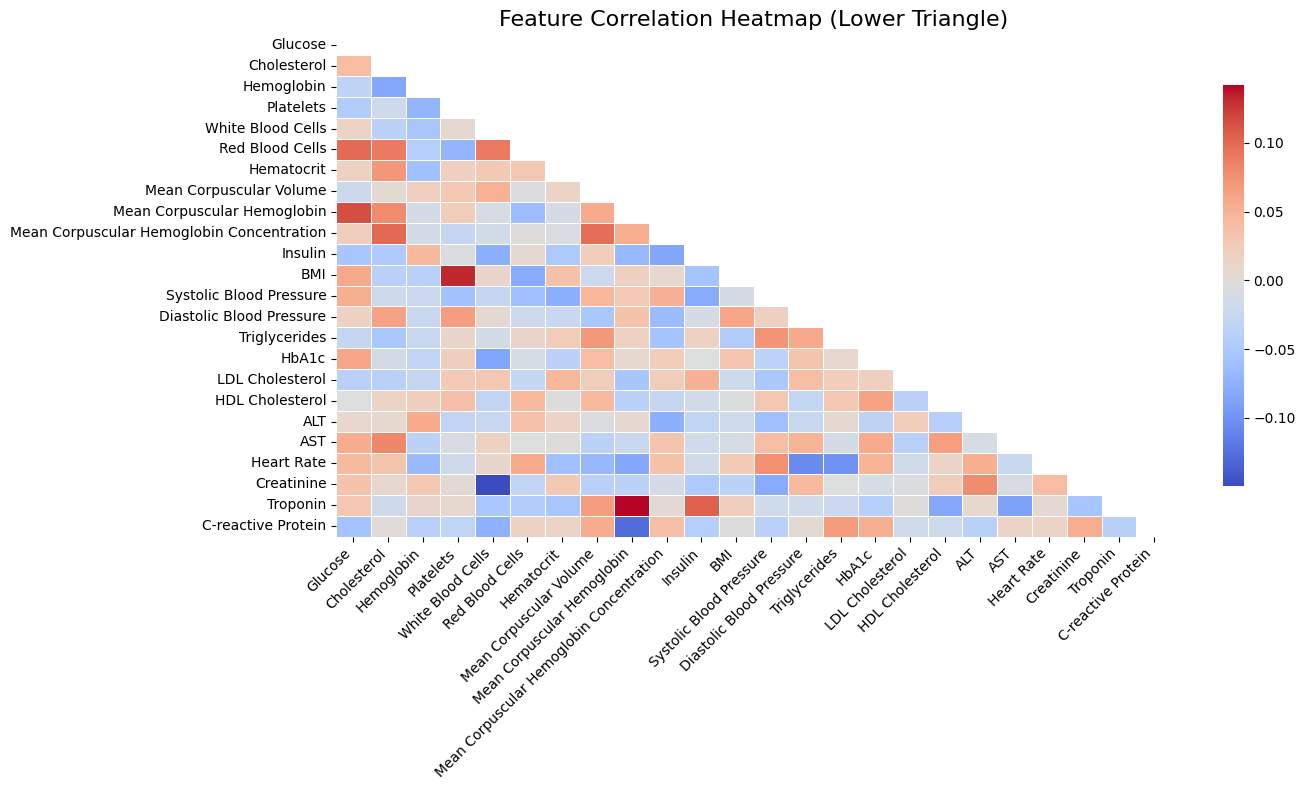

In [262]:
plt.figure(figsize=(14, 8))
corr = data.drop("Disease", axis=1).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Feature Correlation Heatmap (Lower Triangle)", fontsize=16)
plt.tight_layout()
plt.show()


- Most features show low to moderate correlation.
- The dataset does not suffer from serious multicollinearity.
Feature removal is not strictly required, and ML models should perform stably.

### 6. Heart Rate vs Disease (Scatter)

In [263]:
fig = px.scatter(
    data,
    x="Heart Rate",
    y="Cholesterol",
    color="Disease",
    title="Heart Rate vs Cholesterol by Disease",
    width=1200, height=400
)
fig.show()


- Data points from different diseases overlap significantly.
- No clear linear separation between diseases is visible.
- Multi-feature machine learning models are necessary for accurate disease prediction.

## Data Preprocessing

In [264]:
data.duplicated().sum()

np.int64(0)

In [265]:
data.isnull().sum()

Glucose                                      0
Cholesterol                                  0
Hemoglobin                                   0
Platelets                                    0
White Blood Cells                            0
Red Blood Cells                              0
Hematocrit                                   0
Mean Corpuscular Volume                      0
Mean Corpuscular Hemoglobin                  0
Mean Corpuscular Hemoglobin Concentration    0
Insulin                                      0
BMI                                          0
Systolic Blood Pressure                      0
Diastolic Blood Pressure                     0
Triglycerides                                0
HbA1c                                        0
LDL Cholesterol                              0
HDL Cholesterol                              0
ALT                                          0
AST                                          0
Heart Rate                                   0
Creatinine   

- Data is cleaned has no nulls and dupliactes
- all i/p variables in float - encoding not required
- target variable is str so encoding required
- has very low outliers

## Encoding Disease

In [266]:
le = LabelEncoder()
data['Disease_encoded'] = le.fit_transform(data['Disease'])

In [267]:
data['Disease_encoded']

0      4
1      1
2      3
3      1
4      3
      ..
481    1
482    3
483    0
484    1
485    1
Name: Disease_encoded, Length: 486, dtype: int64

### Split input var and target var

In [268]:
x = data.drop(columns=['Disease', 'Disease_encoded'])
y = data['Disease_encoded']

In [269]:
print(x.shape) 
print(y.shape)

(486, 24)
(486,)


In [270]:
x.head()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,Triglycerides,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein
0,0.001827,0.033693,0.114755,0.997927,0.562604,0.866499,0.578042,0.914615,0.026864,0.038641,...,0.970168,0.653230,0.186104,0.430398,0.016678,0.885352,0.652733,0.788235,0.054788,0.031313
1,0.436679,0.972653,0.084998,0.180909,0.675736,0.563889,0.798382,0.670361,0.376092,0.184890,...,0.517805,0.833540,0.153001,0.458533,0.401845,0.635969,0.574425,0.047025,0.607985,0.594123
2,0.545697,0.324815,0.584467,0.475748,0.558596,0.661007,0.934056,0.381782,0.500342,0.531829,...,0.521000,0.678901,0.220479,0.817151,0.690981,0.101633,0.855740,0.551124,0.413294,0.070909
3,0.172994,0.050351,0.736000,0.782022,0.069435,0.085219,0.032907,0.460619,0.785448,0.491495,...,0.944932,0.381500,0.459396,0.420154,0.798537,0.399236,0.324600,0.499504,0.436662,0.242766
4,0.758534,0.739968,0.597868,0.772683,0.875720,0.860265,0.486189,0.486686,0.621048,0.191756,...,0.082744,0.993381,0.272338,0.663579,0.265227,0.918847,0.804910,0.571119,0.188368,0.750848


In [271]:
y.head()

0    4
1    1
2    3
3    1
4    3
Name: Disease_encoded, dtype: int64

### Train-test Split

In [272]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [273]:
print(x_train.shape)     # 80%  
print(x_test.shape)  

(388, 24)
(98, 24)


In [274]:
print(y_train.shape)     # 80%  
print(y_test.shape)  

(388,)
(98,)


### Feature Scailing

In [275]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Random Forest Classifier

In [276]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [277]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [278]:
y_pred = rf_model.predict(x_test)

#### Verify

In [279]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)

R2 Score: 0.8613520329704127
Mean Squared Error: 0.23469387755102042


In [280]:
compare_df = pd.DataFrame({
    'Actual Disease': y_test,
    'Predicted Disease': y_pred
})

compare_df

,Actual Disease,Predicted Disease
420,0,0
262,0,1
431,3,1
448,1,1
364,1,1
...,...,...
353,1,1
323,1,1
299,3,1
271,0,0


In [281]:
fig = px.scatter(compare_df, x='Actual Disease', y='Predicted Disease',
                 title="Actual vs Predicted Disease",
                 width=600, height=450)
fig.show()


In [282]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9387755102040817

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92        20
           1       0.92      1.00      0.96        59
           3       1.00      0.43      0.60         7
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00         3

    accuracy                           0.94        98
   macro avg       0.97      0.87      0.90        98
weighted avg       0.94      0.94      0.93        98


Confusion Matrix:
 [[18  2  0  0  0]
 [ 0 59  0  0  0]
 [ 1  3  3  0  0]
 [ 0  0  0  9  0]
 [ 0  0  0  0  3]]


In [283]:
f1_score(y_test, y_pred, average='macro')

0.8964853033145715

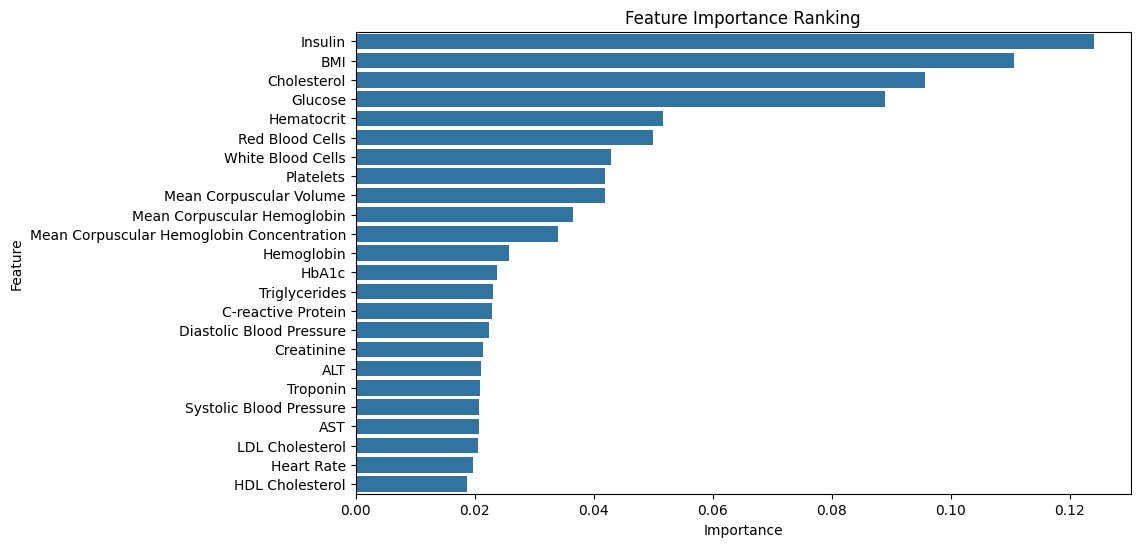

In [284]:
# After training your model on all features
importances = rf_model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance Ranking')
plt.show()

In [285]:
# Top 12 features
top_12 = feature_importance_df['Feature'].head(12).tolist()
print("The 12 features we should keep:", top_12)

The 12 features we should keep: ['Insulin', 'BMI', 'Cholesterol', 'Glucose', 'Hematocrit', 'Red Blood Cells', 'White Blood Cells', 'Platelets', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'Hemoglobin']


## Retrain model with these 12

In [286]:
x_reduced = data[top_12]
y = data['Disease_encoded']

In [287]:
x_reduced.head()

,Insulin,BMI,Cholesterol,Glucose,Hematocrit,Red Blood Cells,White Blood Cells,Platelets,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,Hemoglobin
0,0.645755,0.070888,0.033693,0.001827,0.578042,0.866499,0.562604,0.997927,0.914615,0.026864,0.038641,0.114755
1,0.353929,0.681551,0.972653,0.436679,0.798382,0.563889,0.675736,0.180909,0.670361,0.376092,0.184890,0.084998
2,0.310422,0.454435,0.324815,0.545697,0.934056,0.661007,0.558596,0.475748,0.381782,0.500342,0.531829,0.584467
3,0.819216,0.542478,0.050351,0.172994,0.032907,0.085219,0.069435,0.782022,0.460619,0.785448,0.491495,0.736000
4,0.681771,0.600863,0.739968,0.758534,0.486189,0.860265,0.875720,0.772683,0.486686,0.621048,0.191756,0.597868


In [288]:
y.head()

0    4
1    1
2    3
3    1
4    3
Name: Disease_encoded, dtype: int64

In [289]:
X_train, X_test, y_train, y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

In [290]:
final_model = RandomForestClassifier(
    n_estimators=200, 
    class_weight='balanced', 
    random_state=42
)

# Train the model
final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [291]:
y_pred = final_model.predict(X_test)

#### Verify

In [292]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)

R2 Score: 0.5478870640339546
Mean Squared Error: 0.7653061224489796


In [293]:
compare_df = pd.DataFrame({
    'Actual Disease': y_test,
    'Predicted Disease': y_pred
})

compare_df

,Actual Disease,Predicted Disease
420,0,0
262,0,1
431,3,1
448,1,1
364,1,1
...,...,...
353,1,1
323,1,1
299,3,1
271,0,1


In [294]:
fig = px.scatter(compare_df, x='Actual Disease', y='Predicted Disease',
                 title="Actual vs Predicted Disease",
                 width=600, height=450)
fig.show()


In [295]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.826530612244898

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.55      0.71        20
           1       0.78      1.00      0.87        59
           3       1.00      0.43      0.60         7
           4       1.00      0.78      0.88         9
           5       1.00      0.33      0.50         3

    accuracy                           0.83        98
   macro avg       0.96      0.62      0.71        98
weighted avg       0.87      0.83      0.81        98


Confusion Matrix:
 [[11  9  0  0  0]
 [ 0 59  0  0  0]
 [ 0  4  3  0  0]
 [ 0  2  0  7  0]
 [ 0  2  0  0  1]]


In [296]:
f1_score(y_test, y_pred, average='macro')

0.7117502986857825

In [297]:
joblib.dump(final_model, 'Disease_pred.pkl')

['Disease_pred.pkl']